# Creating an Observable from a Simulation 
When running a refinement, MDMC makes quantitative comparisons between properties measured experimentally and calculated from MD simulations: within MDMC each of these properties is an `Observable`.  Examples of these observables are the dynamic structure factor, $S(Q,\omega)$, and the pair distribution function, $G(r)$.

Within a refinement, each `Observable` is calculated from MD automatically.  However it is also useful to be able to calculate an `Observable` from an MD simulation and plot it, which is demonstrated in this tutorial.

This tutorial requires matplotlib to be installed:

In [2]:
try:
    %matplotlib notebook
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
except ImportError:
    %pip install matplotlib
    try:
        %matplotlib notebook
        import matplotlib.pyplot as plt
        from mpl_toolkits.mplot3d import Axes3D
    except ImportError:
        print('Please restart the kernel so that matplotlib can be imported.')

## Running a simulation

Below we setup and run a simulation of liquid argon so that we have a `Trajectory` from which to calculate an `Observable`.

**As this is minimizing, equilibrating, and running a production run, this should take ~3 minutes to execute**.

In [3]:
from MDMC.MD import *
import numpy as np

# Build universe
universe = Universe(dimensions=38.4441)
Ar = Atom('Ar', charge=0.)
n_units_xyz = universe.dimensions // (1. / 0.0176) ** (1 / 3.)
universe.fill(Ar, num_struc_units=int(np.product(n_units_xyz)))
print('Universe contains {} Ar atoms'.format(len(universe.atom_list)))
Ar_dispersion = Dispersion(universe,
                           (Ar.atom_type, Ar.atom_type),
                           cutoff=8.,
                           vdw_tail_correction=True,
                           function=LennardJones(1.0243, 3.36))

# MD Engine setup
simulation = Simulation(universe,
                        engine="lammps",
                        time_step=10.0,
                        temperature=120.,
                        traj_step=25)

# Energy Minimization and equilibration
simulation.minimize(n_steps=5000)
print("Minimization Complete")
simulation.run(n_steps=20000, equilibration=True)
print("Equilibration Complete")
simulation.run(12000)
trajectory = simulation.trajectory

Universe contains 1000 Ar atoms
LAMMPS output is captured by PyLammps wrapper
LAMMPS output is captured by PyLammps wrapper
Minimization Complete
Equilibration Complete


### 3D surface plotting

Below we define a simple function for plotting 3D surfaces, which we will use for plotting the observables.

In [4]:
def plot_surface(x, y, z):
    fig = plt.figure()
    ax = fig.gca(projection='3d')
    X, Y = np.meshgrid(x, y)
    surf = ax.plot_surface(X, Y, z)
    plt.show()

## Calculating $S(Q,\omega)$

To see which observables can be calculated, use the `help` function to look at the observables module documentation:

In [5]:
from MDMC.trajectory_analysis import observables
help(observables)

Help on package MDMC.trajectory_analysis.observables in MDMC.trajectory_analysis:

NAME
    MDMC.trajectory_analysis.observables - Modules calculating observables from molecular dynamics trajectories

DESCRIPTION
    Observables (/ indicates alias)
    -----------
    DynamicStructureFactor / SQw
    CoherentDynamicStructureFactor / SQwCoherent / SQwCoh / SQw_coh
    PDF / PairDistributionFunction
    IncoherentDynamicStructureFactor / SQwIncoherentSQwIncoh / SQw_incoh
    
    Examples
    --------
    Observables can be instantiated using the names above. For instance an SQw
    observable can be instantiated using either of the aliases:
    
    .. code-block:: python
    
        from MDMC.trajectory_analysis import observables
        sqw = observables.SQw()                     # This line...
        sqw = observables.DynamicStructureFactor()  # ...is equivalent to this line

PACKAGE CONTENTS
    obs
    obs_factory
    pdf
    sqw
    sqw_coh
    sqw_incoh

CLASSES
    MDMC.traje

As is mentioned in the Examples section, each observable may have one or more aliases.  So both `DynamicStructureFactor` or `SQw` can be used for calculating $S(Q,\omega)$.

Some of the details given below are specific to calculating the dynamic structure factor, however the general method can be followed for any observable.

Argon has comparable scattering lengths for both coherent and incoherent scattering, so the total scattering has clear contributions from each.  For the purposes of this tutorial we will simply calculate $S(Q,\omega)_{coh}$ and compare it with experimental data; the exercise of calculating the incoherent and total scattering is left as an exercise for the reader.

In [6]:
sqw_coh = observables.SQwCoh()

The dynamic structure factor has two independent variables, the scattering wavevector, $Q$, and $E$ (or $\hbar\omega) is the energy transfer.

The size of the simulation box defines the spacing (and therefore the lower bound) of $Q$ values; however any Q values can be specified for calculating $S(Q,\omega)$ and MDMC will simply calculate it for valid values.

In [7]:
# Using the arange function from NumPy - this creates an uniform array of floats with a
# start (0.42), stop (3.8) and step (0.3) specified below
Q = np.arange(0.42, 3.8, 0.3)
print('Q will be calculated for values of: {}'.format(Q))

Q will be calculated for values of: [0.42 0.72 1.02 1.32 1.62 1.92 2.22 2.52 2.82 3.12 3.42 3.72]


The total duration of the trajectory defines the smallest spacing of the $E$ values.  If $E$ values are not specified, MDMC will simply calculate the $E$ values with this spacing.  However as there will only be two points in the trajectory from which to calculate the correlations, the statistics will be poor (**should take ~30s to execute**):

<IPython.core.display.Javascript object>


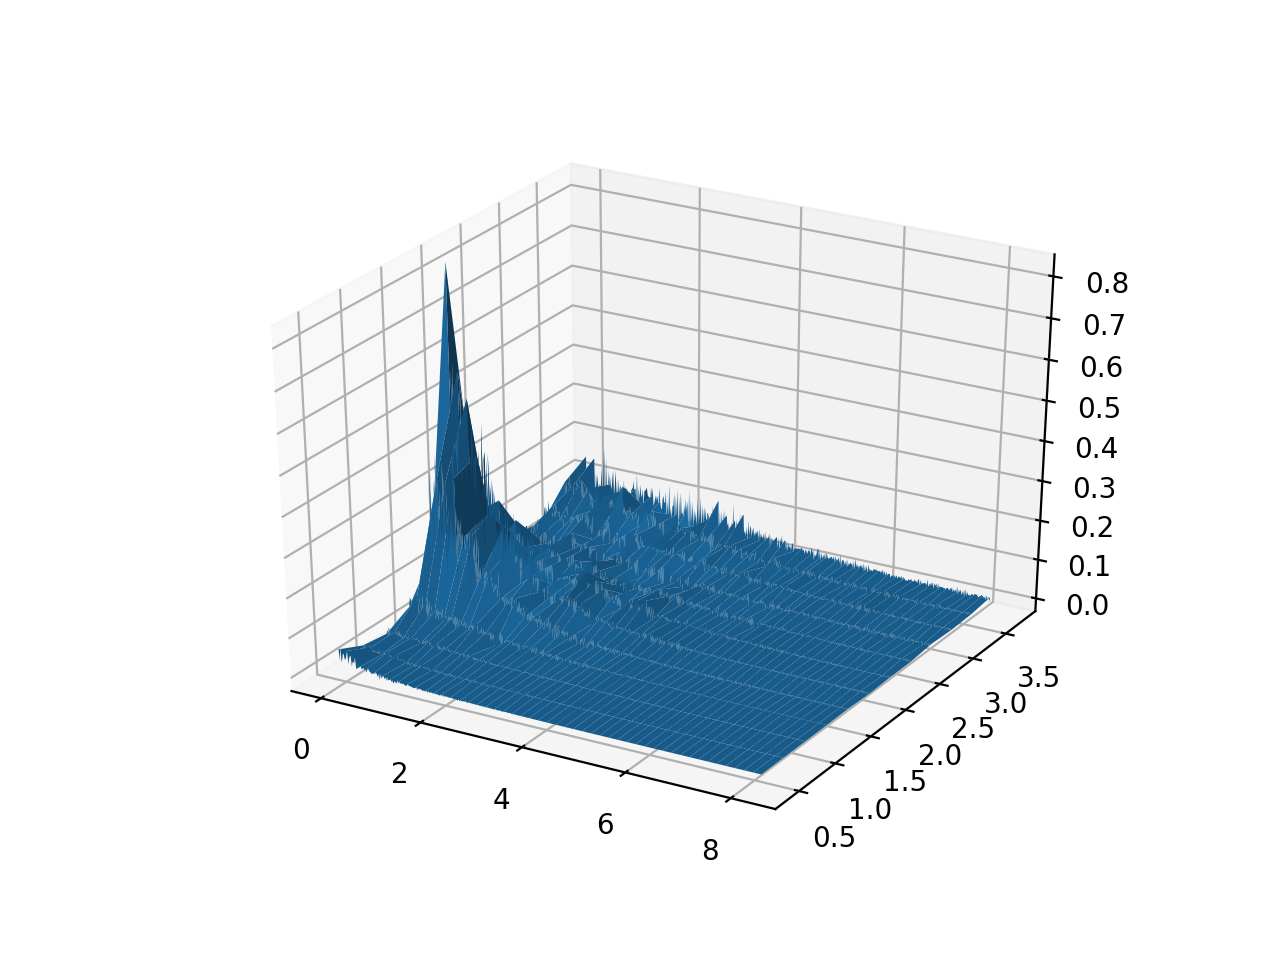

In [8]:
# Set the Q values for the Q independent variable
sqw_coh.independent_variables = {'Q':Q}

# Calculate the coherent dynamic structure factor (t_resolution parameter is explained below)
sqw_coh.calculate_from_MD(trajectory, t_resolution=467.)

# Use the plotting function defined above to plot the result
plot_surface(sqw_coh.E, sqw_coh.Q, sqw_coh.SQw)

Therefore it is strongly recommended that you specify the $E$ values for calculating the dynamic structure factor.

The allowed values of $E$ (in meV) are determined by trajectory times.  To aid in calculating these, the `calulate_E` method 
can be used, which requires the time step of the trajectory (in fs) and the total number of E values to be calculated.  The number of E values should be changed to improve the statistics, but somewhere in the range of 1/4 to 1/8 of the total number of trajectory configurations (i.e. the number of times for which a configuration was recorded) will be probably reasonable:

In [9]:
# This subtracts the time of the zeroeth step from the time of the first step
# It should be equal to the time_step * traj_step passed to Simulation
trajectory_timestep = trajectory.times[1] - trajectory.times[0]
print('Trajectory time step: {} fs'.format(trajectory_timestep))

n_configurations = len(trajectory.times)
print('Number of trajectory configurations: {}'.format(n_configurations))

Trajectory time step: 250.0 fs
Number of trajectory configurations: 480


In [10]:
E = sqw_coh.calculate_E(n_configurations / 6, trajectory_timestep)
print('Calculated E values are: \n{} meV'.format(E))

Calculated E values are: 
[0.         0.10314168 0.20628335 0.30942503 0.4125667  0.51570838
 0.61885005 0.72199173 0.8251334  0.92827508 1.03141675 1.13455843
 1.2377001  1.34084178 1.44398345 1.54712513 1.6502668  1.75340848
 1.85655015 1.95969183 2.0628335  2.16597518 2.26911685 2.37225853
 2.4754002  2.57854188 2.68168355 2.78482523 2.8879669  2.99110858
 3.09425025 3.19739193 3.3005336  3.40367528 3.50681695 3.60995863
 3.7131003  3.81624198 3.91938365 4.02252533 4.125667   4.22880868
 4.33195035 4.43509203 4.5382337  4.64137538 4.74451705 4.84765873
 4.9508004  5.05394208 5.15708375 5.26022543 5.3633671  5.46650878
 5.56965045 5.67279213 5.7759338  5.87907548 5.98221715 6.08535883
 6.1885005  6.29164218 6.39478385 6.49792553 6.6010672  6.70420888
 6.80735055 6.91049223 7.0136339  7.11677558 7.21991725 7.32305893
 7.4262006  7.52934228 7.63248395 7.73562563 7.8387673  7.94190898
 8.04505065 8.14819233] meV


Of course if the $E$ resolution required is lower (i.e. step between the `E` values can be larger), the number of E values specified can be reduced:

In [11]:
print('A reduced E resolution: \n{} meV'.format(sqw_coh.calculate_E(n_configurations / 24, trajectory_timestep)))

A reduced E resolution: 
[0.        0.4125667 0.8251334 1.2377001 1.6502668 2.0628335 2.4754002
 2.8879669 3.3005336 3.7131003 4.125667  4.5382337 4.9508004 5.3633671
 5.7759338 6.1885005 6.6010672 7.0136339 7.4262006 7.8387673] meV


Now we can use `Q` and `E` to set the indepedendent variables of `sqw_coh`:

In [12]:
sqw_coh.independent_variables = {'E':E,
                                 'Q':Q}

For comparison with experimental data, the calculation of the dynamic structure factor also requires the time resolution of the experimental data, with the form of the resolution function assumed to be Gaussian.  **This calculation should take ~30s.**

In [13]:
sqw_coh.calculate_from_MD(trajectory, t_resolution=467.)

Again, we can use the `plot_surface` function we defined above to plot the coherent dynamic structure factor.  As we called `%matploblib` at the start of the tutorial, the plot will be interactive.  It can be rotated by left clicking and dragging, and zoomed by right clicking and dragging.

<IPython.core.display.Javascript object>


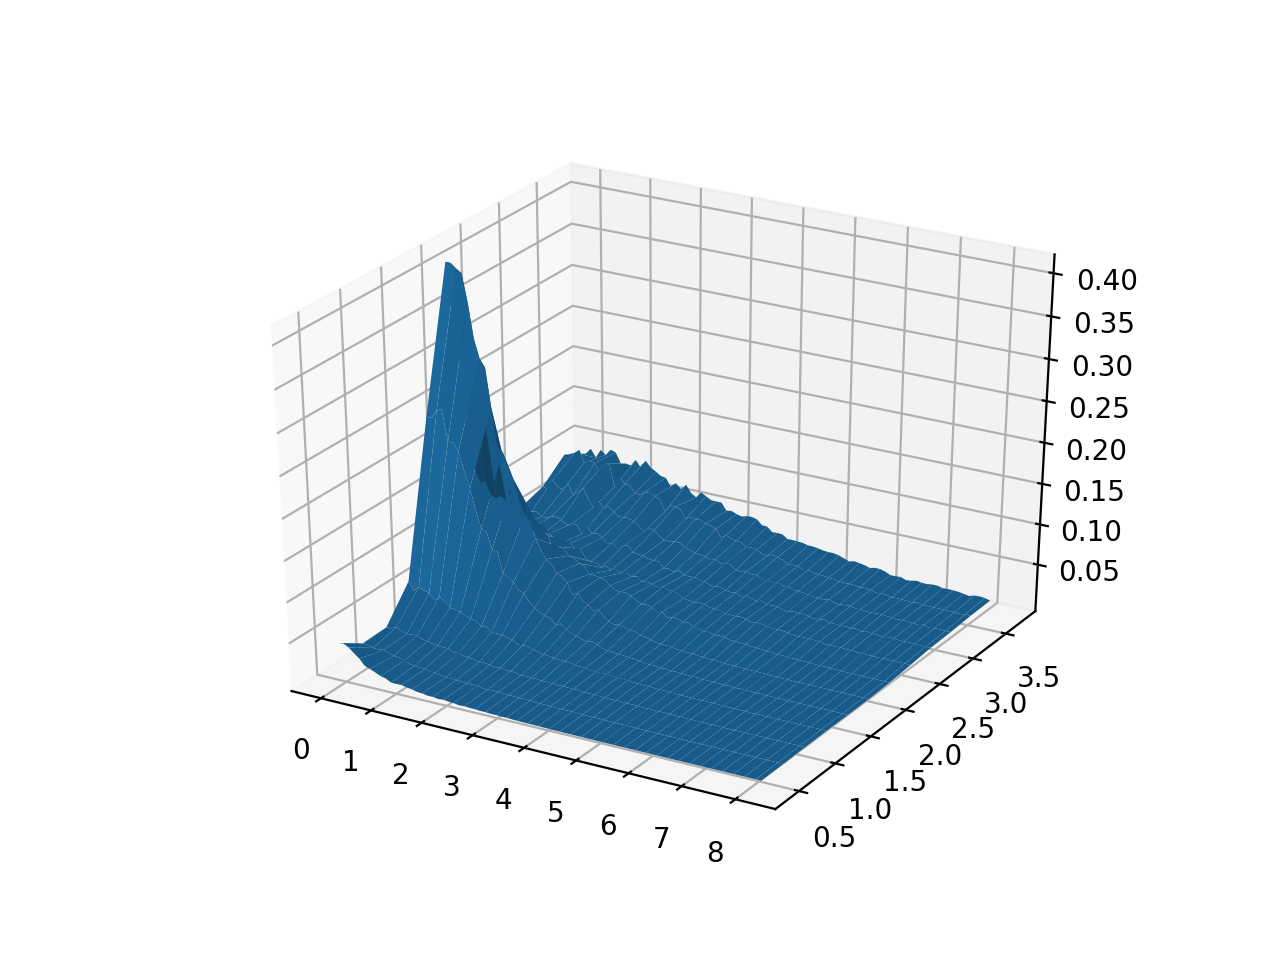

In [14]:
plot_surface(sqw_coh.E, sqw_coh.Q, sqw_coh.SQw)

We can compare this with experimental data measured using quasi-elastic neutron scattering (from van Well et al. Phys. Rev. A **31** 3391 (1985)) by reading the data into an SQwCoh object:

In [15]:
# Create a second SQwCoh object, this time called sqw_exp
sqw_exp = observables.SQwCoh()

# Read the data from the file ./data/Well_s_q_omega_Ar_data.xml using the `xml_SQw` reader
sqw_exp.read_from_file('xml_SQw', './data/Well_s_q_omega_Ar_data.xml')

The independent and dependent variables are read into the same attributes (`sqw_coh.E`, `sqw_exp.Q`, and `sqw_exp.SQw`) as if they had been calculated from MD (as in `sqw_coh` above).  In this instance because the $S(Q, E)_{coh}$ data read from file had the `E` and `Q` axis transposed relative to the MD calculations above, we can use `np.transpose` so that the graph will have equivalent axes. 

<IPython.core.display.Javascript object>


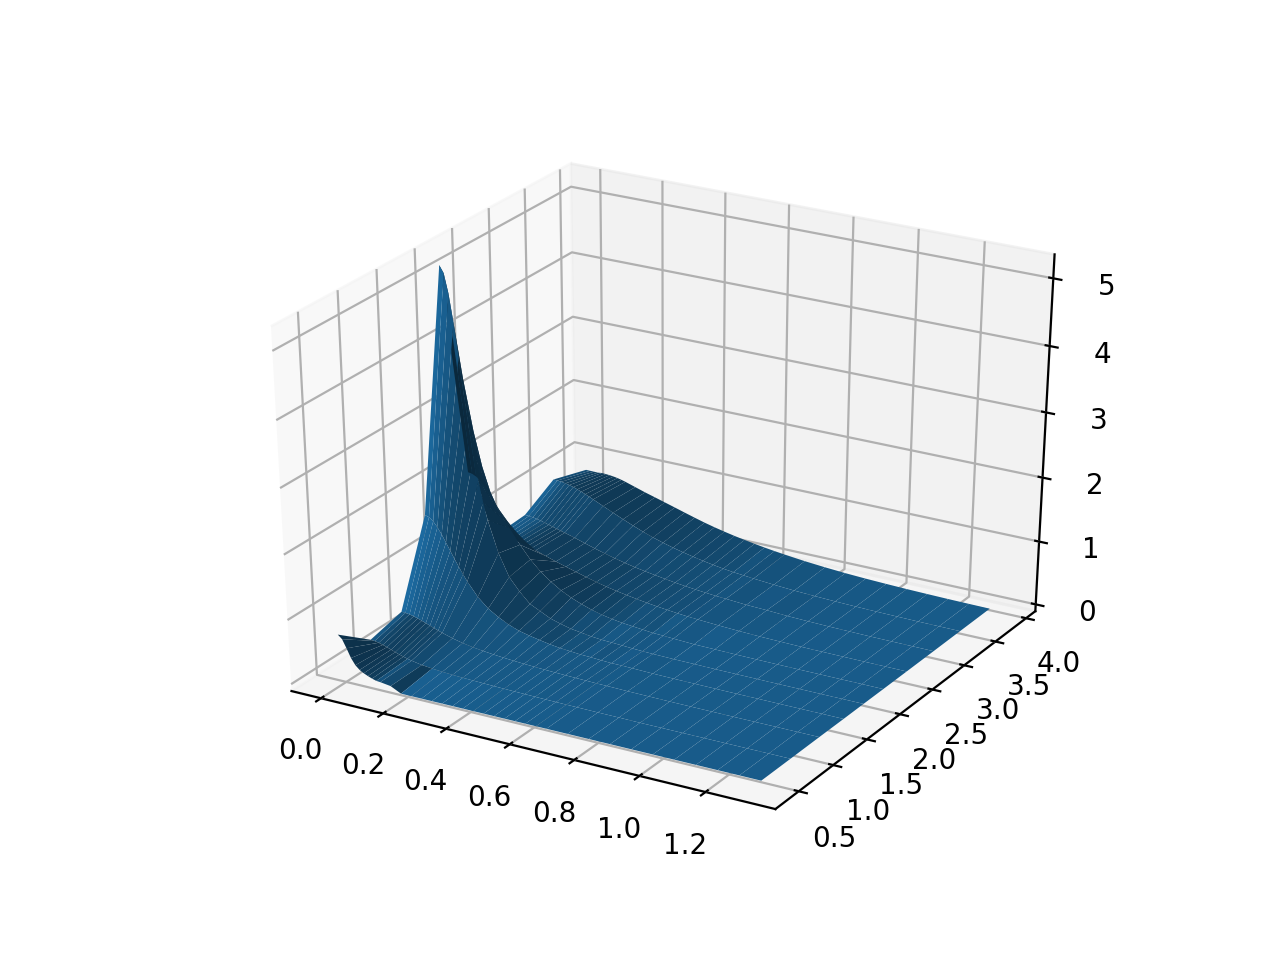

In [16]:
plot_surface(sqw_exp.E, sqw_exp.Q, np.transpose(sqw_exp.SQw))

## Other observables

The same applies for the observables, such as the pair distribution function $G(r)$.  To determine how to calculate another observables from an MD trajectory, please see the associated help documentation:

In [17]:
help(observables.PDF.calculate_from_MD)

Help on function calculate_from_MD in module MDMC.trajectory_analysis.observables.pdf:

calculate_from_MD(self, MD_input, **settings)
    Calculate the pair distribution function, :math:`G(r)`` from a
    ``Trajectory``
    
    The total pair distribution function (``pdf.PDF``) has the form:
    
    .. math::
    
        G(r) = \sum_{i,j}^{N_{elements}} c_ic_jb_ib_j(g_{ij}(r) - 1)
    
    where :math:`c_i` is the number concentration of element :math:`i`,
    :math:`b_i` is the (coherent) scattering length of element :math:`i`,
    and the partial pair distribution, :math:`g_{ij}`, is:
    
    .. math::
    
        g_{ij}(r) = \frac{h_{ij}(r)}{4 \pi r^2 \rho_{j} \Delta{r}}
    
    where :math:`h_{ij}`` is the histogram of distances of :math:`j` element
    atoms around atoms of element :math:`i`, with bins of size
    :math:`\Delta{r}`, and :math:`\rho_{j}` is the number density of
    atoms of element :math:`j`. As :math:`g_{ij}(0) = 0`, it is evident that
    :math:`G(0) = -\s